# 1: Plotting

Nu har i set pakken numpy men en anden pakke som ofte bruges er matplotlib. Dette er en pakke, som
bruges til at lave plots. Pakken hentes på tilsvarende vis
som numpy, hvor det her er alment at importere den som nedenstående, hvor man blot henter pyplot modulet i stedet for hele matplotlib pakken.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

Når man så gerne vil lave et plot skal man overordnet set bruge to ting: noget
at plotte og en funktion der plotter. Lad os starte med at lave noget man kan plotte. Til det vil vi bruge arrays.

In [34]:
x_værdier = np.linspace(0, 2 * np.pi, 100)    # laver et array af 100 værdier fra 0 til 2\pi (np.linspace laver et array med linearly spaced punkter)
y_værdier = np.sin(x_værdier)                 # laver et array af 100 værdier, som består af sinus til hver af x - værdierne fra arrayet ovenfor

Herefter bruger vi plt.plot() funktionen til at plotte. Den kan tage vores 2 arrays som henholdsvis x akse og y akse.

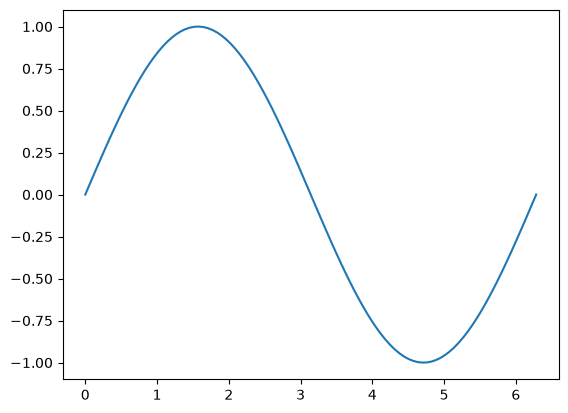

In [35]:
plt.plot(x_værdier, y_værdier)

Det ser jo meget fint ud, men der mangler title, akse labels osv. så lad os lige se på, hvordan man kan justere lidt på plottet.

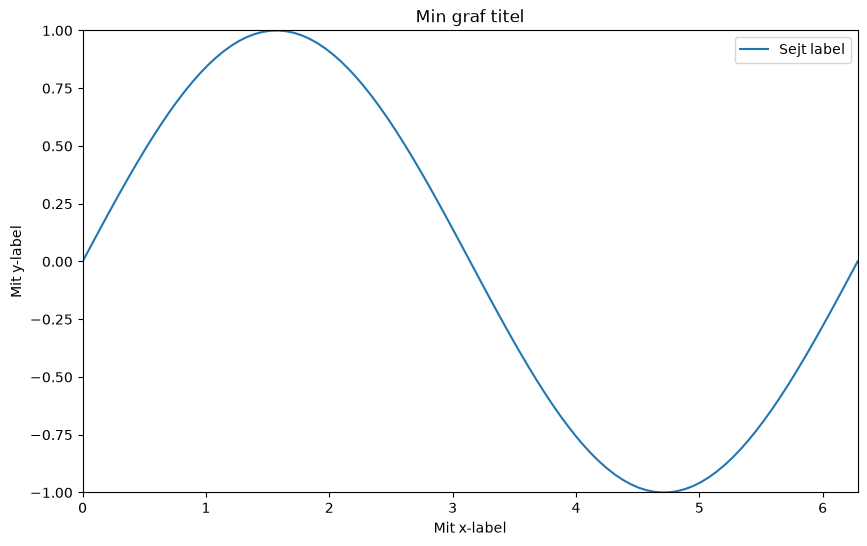

In [36]:
# Bestemmer størrelsen/dimensionerne af billedet
figur = plt.figure(figsize=(10, 6))
# Definerer selve grafen/plottet
plt.plot(x_værdier, y_værdier, label="Sejt label")
# Dette sætter titel på plot
plt.title("Min graf titel")
# sætter y-værdierne til at plotte mellem -1 og 1
plt.ylim(-1, 1)
# sætter x-værdierne til at plotte mellem 0 og 2\pi
plt.xlim(0, 2 * np.pi)
# Dette sætter titlen på din x-akse 
plt.xlabel("Mit x-label")
# Dette sætter titlen på din y-akse 
plt.ylabel("Mit y-label")
# Sørger for at plotte label for selve grafen (den oppe i højre hjørne, der siger "Sejt label")
plt.legend()
# Sikre alt bliver plottet, da labels ellers ikke altid bliver plottet
plt.show()

Man kan også komme flere datasæt/arrays i samme plot. 

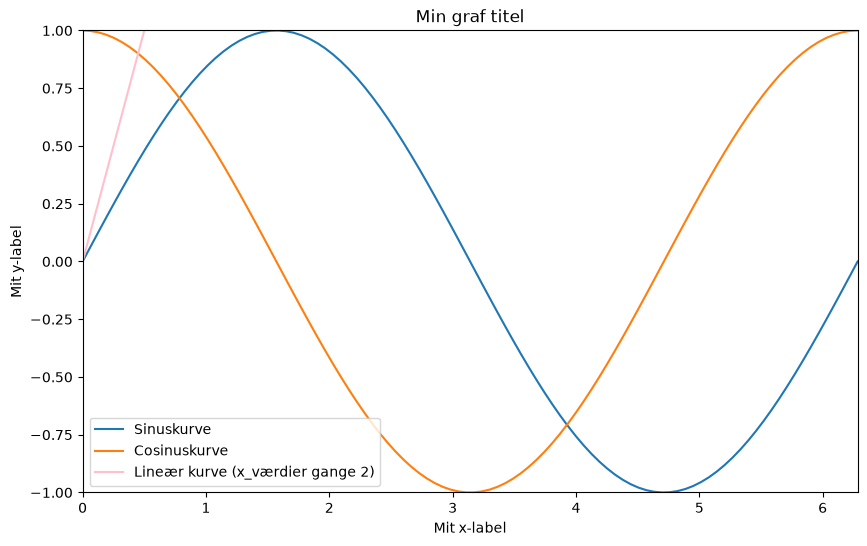

In [37]:
y_værdier_cosinus = np.cos(x_værdier)
y_værdier_lineær = x_værdier * 2

figur = plt.figure(figsize=(10, 6))

plt.plot(x_værdier, y_værdier, label="Sinuskurve")
plt.plot(x_værdier, y_værdier_cosinus, label="Cosinuskurve")
plt.plot(x_værdier, y_værdier_lineær, label="Lineær kurve (x_værdier gange 2)", color = "pink")
plt.title("Min graf titel")
plt.ylim(-1, 1)
plt.xlim(0, 2 * np.pi)
plt.xlabel("Mit x-label")
plt.ylabel("Mit y-label")
plt.legend()
plt.show()

Man kan også importere data fra en fil, og derefter plotte det.

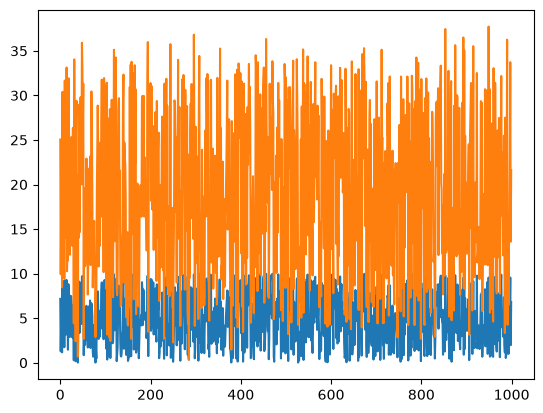

In [38]:
importeret_data = np.loadtxt("dat1.txt")

plt.plot(importeret_data);

Bemærk vores importeret_data array består af 2 arrays, og vi derfor får 2 plots. x-aksen antages her at være antallet af elementer per array, så fordi der er 1000 elementer i hvert array bliver x-aksen 1000 lang. Ovenstående plot giver os ikke så meget information om hvordan vi skal betragte datasættet, så lad os tage andre midler i brug.

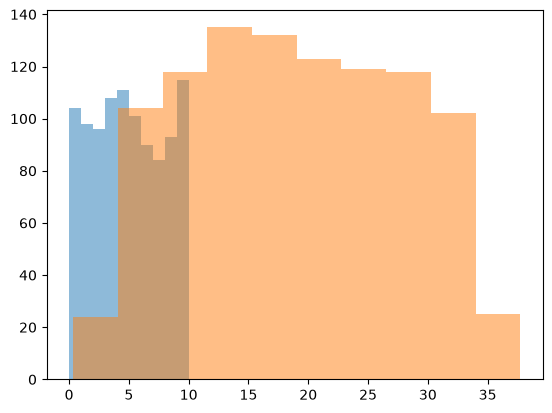

In [39]:
x = importeret_data[:,0]
y = importeret_data[:,1]

plt.hist(x, alpha=0.5);
plt.hist(y, alpha=0.5);

I en optimistisk verden (set fra en fysikers perspektiv) kunne histogrammerne godt indikerer vi har nogle rigtig grimme normalfordelinger. Lad os prøve lidt mere af.

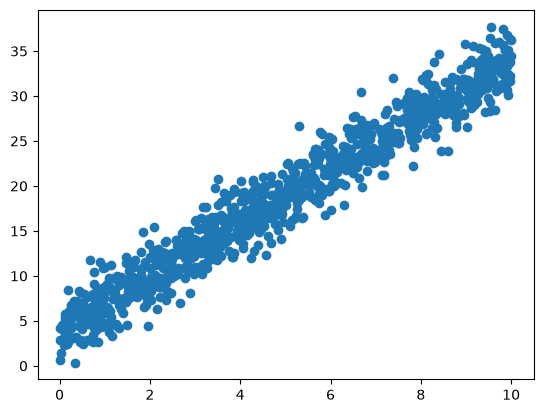

In [40]:
plt.scatter(importeret_data[:,0], importeret_data[:,1]);

Her begynder vi at se noget, der kunne tyde på en sammenhæng. Lad os prøve at lave et lineært fit til dataen. Hertil kan vi benytte LinearRegression fra scikit-learn. I machine learning kaldes fitningen ofte for "træning" af modellen, men konceptuelt er det det samme som at fitte en kurve. Bemærk at scikit-learn forventer, at input-variablen x er 2-dimensionel, derfor bruger vi .reshape(-1, 1) til at omdanne vores 1D-array til en kolonnevektor. Bemærk brugen af from i import linjen, som følge af at vi importerer netop en enkelt ting fra en pakke fremfor at importere selve pakken.

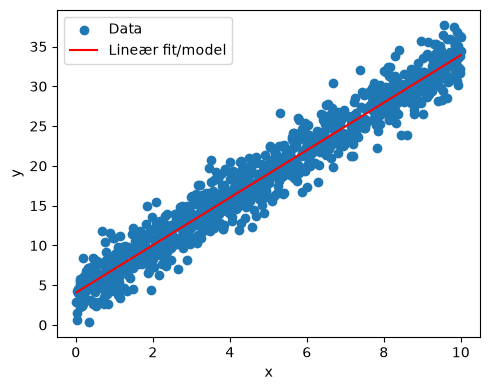

In [65]:
from sklearn.linear_model import LinearRegression

# Her bruger vi LinearRegression til at fitte en lineær model til dataen
# sklearn forventer x som 2D, derfor reshaper vi
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

# Hældning (a) findes i model.coef_, og skæring med y-aksen (b) i model.intercept_
a = model.coef_[0]
b = model.intercept_

# Her definerer vi plottet/grafen for vores fit/model
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit.reshape(-1, 1))

plt.figure(figsize=(5, 4))
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="Lineær fit/model", color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

Det ser jo egentlig meget godt ud, men der sker en masse nye ting her. model.coef_ og model.intercept_ er attributter på vores model, som bliver sat når vi kalder model.fit(). De indeholder henholdsvis hældningen (a) og skæringen med y-aksen (b) for den fittede linje. I machine learning bruger man model.predict() til at lave forudsigelser med den trænede model.

Lad os se, hvor godt modellen egentlig passer til dataen. Her kan vi bruge model.score(), som returnerer R²-værdien — et mål for hvor stor en del af variationen i dataen modellen forklarer. En R² på 1 betyder perfekt fit, og 0 betyder at modellen er lige så god som at gætte gennemsnittet.

In [68]:
R2 = model.score(x.reshape(-1, 1), y)

# Residualer er forskellen mellem data og modelens forudsigelse
residualer = y - model.predict(x.reshape(-1, 1))

print(f"Hældning (a) = {a:.6g}")
print(f"Skæring  (b) = {b:.6g}")
print(f"R²           = {R2:.4f}")
print(f"Residualer:   min={residualer.min():.3g}, max={residualer.max():.3g}, "
      f"std={residualer.std():.3g}")

Hældning (a) = 2.98664
Skæring  (b) = 4.05096
R²           = 0.9500
Residualer:   min=-5.9, max=6.78, std=1.99


En R² tæt på 1 bekræfter at modellen passer godt til dataen. Residualerne viser, hvor store afvigelser der er mellem data og model — små og jævnt fordelte residualer er et tegn på, at modellen fanger mønsteret godt. Det er vigtigt at kende afvigelserne i sin data for at kunne vurdere, om modellen er troværdig 🤷

Lad os plotte residualerne for at se, om der er et systematisk mønster i afvigelserne.

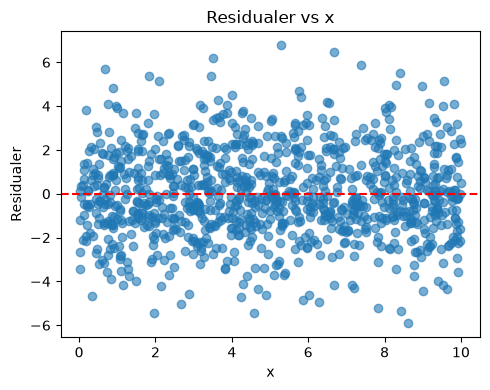

In [69]:
plt.figure(figsize=(5, 4))
plt.scatter(x, residualer, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("x")
plt.ylabel("Residualer")
plt.title("Residualer vs x")
plt.tight_layout()
plt.show()

Hvis residualerne spreder sig tilfældigt om nul, er det et godt tegn, da det betyder at modellen har fanget det underliggende mønster. Hvis der derimod er et tydeligt systematisk mønster (f.eks. en kurve), tyder det på at en lineær model ikke er tilstrækkelig, og vi måske skal prøve en mere kompleks model.

### Opgaver

##### Opgave 1.1
Brug plt.plot() til at plotte en eksponentialfunktion på x-værdierne fra første eksempel med plotting. Tilføj derefter titel, akse labels og eventuel andet dekoration indtil plottet ser rigtig pænt ud :)

In [44]:
# Din kode her

##### Opgave 1.2
Importer data fra filerne dat2.txt, dat3.txt og undersøg dem ligesom i eksemplet foroven.

In [45]:
# Din kode her

# 2: Pandas og Kaggle

Udover at importere lokale filer med data, så man man også bruge kagglehub pakken til at hente data fra [Kaggle](https://www.kaggle.com), som er internettets største samlingssted for datasæt.

In [47]:
import kagglehub

sti = kagglehub.dataset_download("abcsds/pokemon")
print("Datasættet ligger her:", sti)

Datasættet ligger her: /home/vm/.cache/kagglehub/datasets/abcsds/pokemon/versions/2


Her har vi hentet et Pokémon-datasæt fra Kaggle. `kagglehub.dataset_download` downloader
datasættet (første gang) og fortæller os, hvilken mappe det ligger i.

Nu introducerer vi pandas pakken og bruger
`pd.read_csv` til at indlæse CSV-filen som en **DataFrame**. DataFrames kan vi tænke på som tabeller.

In [48]:
import pandas as pd

df = pd.read_csv(sti + "/Pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Hvad kigger vi på?

`df.head()` viser de første 5 rækker. Kolonnerne betyder:

| Kolonne | Betydning |
|---|---|
| `#` | Pokémonens nummer i Pokédex'en (bemærk: Mega-udgaver deler nummer) |
| `Name` | Navnet |
| `Type 1` / `Type 2` | Typen(-erne) — fx Grass, Fire, Water. Ikke alle har en Type 2! |
| `Total` | Summen af de seks stats nedenfor — et groft mål for samlet styrke |
| `HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed` | De seks kamp-stats |
| `Generation` | Hvilken spilgeneration (1–6) den kommer fra |
| `Legendary` | `True` hvis den er legendarisk 🌟 |

**Én vigtig detalje:** flere kolonnenavne indeholder mellemrum (`Sp. Atk`, `Type 1`).
Derfor skriver vi altid `df["Sp. Atk"]` med kantede parenteser og anførselstegn — det virker for alle kolonnenavne, altid.

### Opgaver

##### Opgave 2.1
Kør download-cellen ovenfor (hvis I ikke allerede har gjort det) og kig på stien, der bliver
printet. Åbn filpanelet i venstre side af Colab (📁-ikonet) og se, om I kan finde `Pokemon.csv`.
Hvor mange **rækker** og **kolonner** har tabellen? (Psst: kør cellen nedenunder.)

In [49]:
df.shape  # (rækker, kolonner)

(800, 13)

##### Opgave 2.2
Kig på tabellen fra `df.head()`. Hvilke kolonner indeholder **tal**, og hvilke indeholder
**tekst eller sandt/falsk**? Hvorfor er det vigtigt at vide, når en computer skal regne på
dataene?

*Skriv jeres svar her:* $\dots$

##### Opgave 2.3
`df.head()` kan tage et tal i parentesen. Prøv at ændre tallet i cellen nedenfor — hvad gør det?
Og hvad gør `df.tail()` mon?

In [50]:
df.head()  # prøv fx df.head(10) — og bagefter df.tail(3)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


# 3: Mere om DataFrames

En DataFrame er som et regneark med turbo på: I kan udvælge, filtrere, sortere og regne på
hundredtusindvis af rækker med én linje kode. Lad os tage værktøjerne ét ad gangen.

Én kolonne med `df["Name"]` — flere kolonner med **dobbelte** kantede parenteser
(fordi man giver pandas en *liste* af kolonnenavne):

In [51]:
df[["Name", "HP", "Speed"]].head()

,Name,HP,Speed
0,Bulbasaur,45,45
1,Ivysaur,60,60
2,Venusaur,80,80
3,VenusaurMega Venusaur,80,80
4,Charmander,39,65


`df.iloc[i]` giver række nummer `i` (regnet fra 0 — som altid i Python), og man kan slice
ligesom i numpy:

In [52]:
df.iloc[0]        # den allerførste Pokémon (gæt hvem 😉)

#                     1
Name          Bulbasaur
Type 1            Grass
Type 2           Poison
Total               318
HP                   45
Attack               49
Defense              49
Sp. Atk              65
Sp. Def              65
Speed                45
Generation            1
Legendary         False
Name: 0, dtype: object

In [53]:
df.iloc[10:13]    # række 10, 11 og 12

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
10,8,Wartortle,Water,NaN,405,59,63,80,65,80,58,1,False
11,9,Blastoise,Water,NaN,530,79,83,100,85,105,78,1,False
12,9,BlastoiseMega Blastoise,Water,NaN,630,79,103,120,135,115,78,1,False


Det her er pandas' fedeste trick kaldet Boolean-masker. `df["HP"] > 150` spørger *alle 800 rækker på én gang*
"er din HP over 150?" og svarer med 800 gange `True`/`False`. Putter man svaret ind i
`df[...]`, får man kun rækkerne med `True`:

In [54]:
df["HP"] > 150            # 800 svar: True eller False

0      False
1      False
2      False
3      False
4      False
       ...  
795    False
796    False
797    False
798    False
799    False
Name: HP, Length: 800, dtype: bool

In [55]:
df[df["HP"] > 150]        # kun rækkerne hvor svaret var True

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
121,113,Chansey,Normal,NaN,450,250,5,5,35,105,50,1,False
155,143,Snorlax,Normal,NaN,540,160,110,65,65,110,30,1,False
217,202,Wobbuffet,Psychic,NaN,405,190,33,58,33,58,33,2,False
261,242,Blissey,Normal,NaN,540,255,10,10,75,135,55,2,False
351,321,Wailord,Water,NaN,500,170,90,45,90,45,60,3,False
655,594,Alomomola,Water,NaN,470,165,75,80,40,45,65,5,False


Flere betingelser kombineres med `&` (og) samt `|` (eller). **Hver betingelse SKAL stå i
sin egen parentes** — ellers bliver Python forvirret og kaster en lang, sur fejlbesked
(det kommer I til at opleve i opgave 3.4 😈):

In [56]:
hurtige_taenks = df[(df["Defense"] > 100) & (df["Speed"] > 100)]
hurtige_taenks[["Name", "Defense", "Speed"]].head()

,Name,Defense,Speed
137,PinsirMega Pinsir,120,105
269,Lugia,130,110
409,SalamenceMega Salamence,130,120
413,MetagrossMega Metagross,150,110
418,LatiasMega Latias,120,110


- `sort_values("kolonne")` sorterer — `ascending=False` giver størst først.
- `value_counts()` tæller, hvor mange gange hver værdi optræder.
- `describe()` giver statistik (middelværdi, spredning, min/max...) for alle talkolonner på én gang.

In [57]:
# Hvem er hurtigst i hele Pokédex'en?
df.sort_values("Speed", ascending=False)[["Name", "Speed"]].head()

,Name,Speed
431,DeoxysSpeed Forme,180
315,Ninjask,160
71,AlakazamMega Alakazam,150
429,DeoxysAttack Forme,150
154,AerodactylMega Aerodactyl,150


In [58]:
df["Type 1"].value_counts()

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

In [59]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


### Opgaver

##### Opgave 3.1
Koden nedenfor viser de **første 5** rækker. Ændr den, så den viser de **sidste 10**.

In [60]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


##### Opgave 3.2
Koden viser `Name` og `HP`. Ændr den, så den viser `Name`, `Attack` og `Speed` — sorteret
efter `Attack` med den største først.

In [61]:
df[["Name", "HP"]].head()

,Name,HP
0,Bulbasaur,45
1,Ivysaur,60
2,Venusaur,80
3,VenusaurMega Venusaur,80
4,Charmander,39


##### Opgave 3.3
Udfyld boolean-masken, så I kun ser Pokémon med `Speed` over 100.

In [62]:
hurtige = df[df[...] > ...]
hurtige[["Name", "Speed"]].head()

KeyError: Ellipsis

##### Opgave 3.4 🐛
Koden nedenfor SKULLE finde Pokémon, der både har `HP` over 100 **og** `Speed` over 100...
men den crasher med en lang fejlbesked. Læs det sidste linje af fejlbeskeden — og ret så
koden (hint: afsnittet om parentes-reglen).

In [ ]:
staerke_og_hurtige = df[df["HP"] > 100 & df["Speed"] > 100]
staerke_og_hurtige[["Name", "HP", "Speed"]]

##### Opgave 3.5
Cellen tæller, hvor mange Pokémon der findes af hver `Type 1`. Prøv også med `Type 2` og
`Generation`. Hvilken type er den mest almindelige — og hvilken er den mest sjældne?

In [ ]:
df["Type 1"].value_counts()

##### Opgave 3.6
Brug en boolean-maske til at finde **Pikachu** og se dens stats. Udfyld navnet i masken.
Er Pikachu egentlig så sej, som serien påstår? ⚡

In [ ]:
df[df["Name"] == ...]

##### Opgave 3.7
Kør `describe()`-cellen ovenfor igen og kig på rækken **std** (standardafvigelsen — et mål
for hvor *spredte* værdierne er). Hvilken af de seks kamp-stats har den største spredning?
Hvad betyder det i praksis?

*Skriv jeres svar her:* $\dots$

##### Opgave 3.8 ⭐
Find de 5 stærkeste **ikke-legendariske** Pokémon (målt på `Total`). I skal kombinere tre
ting i én pipeline: en maske der frasorterer legendariske (`==False` eller `~`), en sortering
og en `head`. Start fra koden nedenfor.

In [ ]:
# Byg videre på denne — lige nu viser den bare de 5 stærkeste OVERHOVEDET
df.sort_values("Total", ascending=False)[["Name", "Total", "Legendary"]].head()

##### Opgave 3.9 🐛
Koden nedenfor skulle vise de stærkeste Pokémon ØVERST... men tabellen er stadig i den gamle
rækkefølge, og de svageste ligger først når man endelig sorterer. Der er **to** problemer —
find og ret dem begge.

In [ ]:
df.sort_values("Total")
df.head()

##### Opgave 3.10 ⭐
Hvor mange **legendariske** Pokémon er der i hver generation? Udfyld koden: filtrér først
til kun legendariske, og tæl så med `value_counts()` på `Generation`.

In [ ]:
legendariske = df[df[...] == ...]
legendariske[...].value_counts()

# 4: Datarensning — den virkelige verden er rodet

Rigtige datasæt har huller: en sensor der svigtede, et spørgeskema-felt der ikke blev udfyldt,
en Pokémon der bare ikke *har* nogen anden type. Manglende værdier hedder `NaN`
(*Not a Number*), og de skal håndteres, før man kan lave ML — ellers brokker modellerne sig.

`isna()` spørger hver celle "mangler du?", og `.sum()` tæller op pr. kolonne:

In [ ]:
df.isna().sum()

386 Pokémon mangler `Type 2` — det er ikke en fejl i data, de har bare kun én type!

Der er to klassiske strategier:

1. **`fillna(værdi)`** — udfyld hullerne med noget fornuftigt.
2. **`dropna()`** — smid alle rækker med huller ud. Hurtigt, men brutalt: man mister data!

Ligesom `sort_values` ændrer de ikke den oprindelige tabel — de returnerer en ny, som man
selv skal gemme:

In [ ]:
df_udfyldt = df.fillna("Ingen")
df_udfyldt.head()   # kig på Type 2 for fx Charmander

In [ ]:
df_uden_huller = df.dropna()
print("Før: ", df.shape)
print("Efter:", df_uden_huller.shape)   # av — der røg nogle rækker!

Man kan lave en ny kolonne ud fra de gamle med almindelig matematik — pandas regner så
for alle 800 rækker samtidig:

In [ ]:
df["Offensiv"] = df["Attack"] + df["Sp. Atk"]
df.sort_values("Offensiv", ascending=False)[["Name", "Attack", "Sp. Atk", "Offensiv"]].head()

`groupby("Type 1")` deler tabellen op i ét hold pr. type. Derefter vælger man en kolonne og
en udregning — fx gennemsnittet af `Attack` pr. type:

In [ ]:
df.groupby("Type 1")["Attack"].mean().sort_values(ascending=False)

ML-modeller spiser kun tal. Kolonnen `Legendary` indeholder `True`/`False`, men med
`astype(int)` bliver det til 1/0 — klar til en model:

In [ ]:
df["Legendary_tal"] = df["Legendary"].astype(int)
df[["Name", "Legendary", "Legendary_tal"]].tail()   # de sidste rækker er legendariske

### Opgaver

##### Opgave 4.1
Kør `df.isna().sum()` igen. Hvorfor giver det god mening, at det netop er `Type 2`, der
mangler værdier — og hvad *betyder* et hul i den kolonne egentlig?

*Skriv jeres svar her:* $\dots$

##### Opgave 4.2
Koden bruger `fillna("Ingen")`. Skift til `dropna()` og sammenlign `shape` før og efter.
Præcis hvor mange Pokémon mistede I — og hvilke Pokémon er det, der ryger ud?

In [ ]:
ny_df = df.fillna("Ingen")
print("Før: ", df.shape)
print("Efter:", ny_df.shape)

##### Opgave 4.3
Lav kolonnen `Angreb_pr_Forsvar` som `Attack` divideret med `Defense` — udfyld formlen.
En høj værdi betyder "kanon som kan skyde, men er lavet af glas" 🥃. Hvilken Pokémon er
datasættets største glaskanon?

In [ ]:
df["Angreb_pr_Forsvar"] = df["Attack"] / ...
df.sort_values("Angreb_pr_Forsvar", ascending=False)[["Name", "Attack", "Defense", "Angreb_pr_Forsvar"]].head()

##### Opgave 4.4
`Offensiv`-kolonnen fik vi lavet ovenfor. Lav på samme måde en `Defensiv`-kolonne
(`Defense` + `Sp. Def`) og find den mest defensive Pokémon i hele datasættet.

In [ ]:
df["Offensiv"] = df["Attack"] + df["Sp. Atk"]
df.sort_values("Offensiv", ascending=False)[["Name", "Offensiv"]].head()

##### Opgave 4.5 🐛
Nogen ville regne gennemsnittet af angrebs-statten, men pandas kaster en `KeyError`.
Kør cellen, læs fejlbeskeden, og ret fejlen. (Hint: `df.columns` viser alle kolonnenavne,
præcis som de er stavet.)

In [ ]:
df["attack"].mean()

##### Opgave 4.6
Udfyld `groupby`-koden, så I finder den type (`Type 1`), der har det højeste
**gennemsnitlige** `Attack`.

In [ ]:
df.groupby(...)[...].mean().sort_values(ascending=False)

##### Opgave 4.7
Er der *power creep* i Pokémon? Brug `groupby` på `Generation` og tag gennemsnittet af
`Total`. Bliver Pokémon stærkere for hver generation — hvad siger tallene?

In [ ]:
df.groupby("Generation")["Total"].mean()

##### Opgave 4.8 ⭐
Lav en kolonne `Hurtigere_end_staerk`, der er `True`, når `Speed` er større end `Attack`.
Brug derefter `.mean()` på kolonnen til at finde ud af, hvor stor en **andel** af alle
Pokémon det gælder for. (Hvorfor giver `.mean()` på en True/False-kolonne en andel? Tænk
over, hvad `True` er som tal...)

In [ ]:
df["Hurtigere_end_staerk"] = ...
df["Hurtigere_end_staerk"].mean()

##### Opgave 4.9
Forestil jer, at tabellen ikke var Pokémon, men **patienter på et hospital**, og at kolonnen
med huller var "resultat af blodprøve". Hvorfor kan det være direkte farligt bare at køre
`dropna()` og smide alle rækker med huller ud?

*Skriv jeres svar her:* $\dots$

# 5: Plots og tal-gymnastik — gør data klar til ML

Tal i en tabel er svære at *fornemme*. Et godt plot afslører på ét sekund mønstre, som man
kunne stirre på tallene i timevis uden at se. Og til sidst i dette afsnit lærer I det
vigtigste ML-forberedelsestrick af dem alle: **standardisering**.

I kender allerede numpy. En pandas-kolonne kan når som helst omdannes til et numpy-array
med `.values` — så alt, hvad I har lært om numpy, virker stadig:

In [ ]:
hp = df["HP"].values
print(type(hp))
print(hp[:10])
print("gennemsnit:", hp.mean().round(1))

Vi kan bruge histogrammer til at se hvordan stats fordeler sig

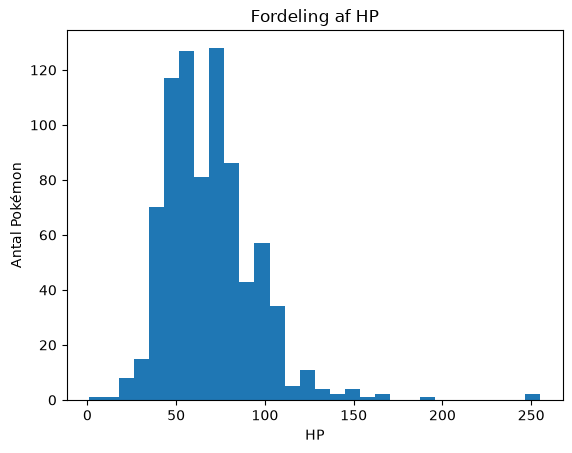

In [ ]:
plt.hist(df["HP"], bins=30)
plt.title("Fordeling af HP")
plt.xlabel("HP")
plt.ylabel("Antal Pokémon")
plt.show()

Scatterplots kan bruges til at undersøge om stats hænger sammen

In [ ]:
plt.scatter(df["Attack"], df["Defense"], alpha=0.5)
plt.title("Attack mod Defense")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.show()

Kalder man `plt.scatter` to gange, ender begge grupper i samme figur — og med `label` +
`plt.legend()` kan man se, hvem der er hvem. Kan man *se* de legendariske i punktskyen?

In [ ]:
almindelige = df[df["Legendary"] == False]
legendariske = df[df["Legendary"] == True]

plt.scatter(almindelige["Attack"], almindelige["Defense"], alpha=0.4, label="Almindelig")
plt.scatter(legendariske["Attack"], legendariske["Defense"], color="red", label="Legendarisk 🌟")
plt.title("Attack mod Defense")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.legend()
plt.show()

`value_counts()` fra afsnit 3 kan plottes direkte:

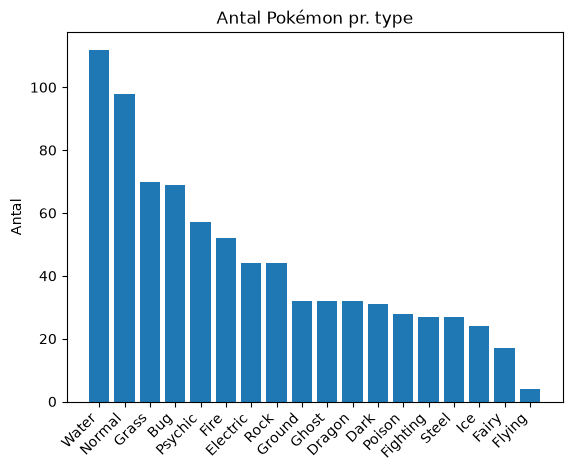

In [ ]:
antal = df["Type 1"].value_counts()
plt.bar(antal.index, antal.values)
plt.title("Antal Pokémon pr. type")
plt.xticks(rotation=45, ha="right")   # drej navnene så de kan læses
plt.ylabel("Antal")
plt.show()

**Korrelation** måler, hvor meget to kolonner følges ad — fra −1 (modsat) over 0 (intet
mønster) til +1 (helt i takt). `df.corr()` regner den for alle par af talkolonner, og med
`plt.imshow` kan vi tegne resultatet som et farvekort:

In [ ]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Total"]
korr = df[stats].corr(numeric_only=True)

plt.imshow(korr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="korrelation")
plt.xticks(range(len(stats)), stats, rotation=45, ha="right")
plt.yticks(range(len(stats)), stats)
plt.title("Korrelation mellem stats")
plt.show()

Et af de vigtigste data science tricks før ML er standardisering

Kig på tallene: `HP` ligger typisk mellem 20 og 150, men forestil jer et datasæt med både
"alder" (0–100) og "årsløn" (0–1.000.000). En ML-model, der får begge tal råt ind, vil tro,
at løn er 10.000 gange vigtigere end alder — bare fordi tallene er større!

Løsningen er at **standardisere** hver kolonne, så den får gennemsnit 0 og spredning 1:

$$x_{\text{ny}} = \frac{x - \text{gennemsnit}}{\text{spredning}}$$

Efter standardisering betyder $x_{\text{ny}} = 2$ altså "2 spredninger over gennemsnittet" —
uanset om kolonnen var HP eller årsløn. Alle kolonner taler pludselig samme sprog.

**Gem denne celle i baghovedet** — i notebook 2 og 3 skal I se, hvad der sker med et neuralt
netværk, når man *glemmer* at standardisere. Det er ikke kønt. 💀

In [ ]:
attack = df["Attack"].values
attack_std = (attack - attack.mean()) / attack.std()

fig, akser = plt.subplots(1, 2, figsize=(11, 4))
akser[0].hist(attack, bins=30)
akser[0].set_title("Attack — rå tal")
akser[1].hist(attack_std, bins=30, color="orange")
akser[1].set_title("Attack — standardiseret")
plt.show()

print("Før:  gennemsnit =", attack.mean().round(2), " spredning =", attack.std().round(2))
print("Efter: gennemsnit =", attack_std.mean().round(2), " spredning =", attack_std.std().round(2))

Bemærk: histogrammet har **præcis samme facon** — vi har ikke ødelagt nogen information,
kun flyttet og skaleret tallene, så de er nemme for en model at arbejde med.

### Opgaver

##### Opgave 5.1
Histogram-koden viser fordelingen af `HP`. Skift kolonnen til `Speed`, og prøv `bins=10`
og `bins=60`. Hvad gør `bins`? Og hvordan vil I beskrive fordelingen af Speed med ét ord?

In [ ]:
plt.hist(df["HP"], bins=30)
plt.title("Fordeling af HP")
plt.xlabel("HP")
plt.ylabel("Antal Pokémon")
plt.show()

##### Opgave 5.2
Udfyld scatterplottet, så det viser `Sp. Atk` mod `Sp. Def` — med aksetitler!

In [ ]:
plt.scatter(df[...], df[...], alpha=0.5)
plt.xlabel(...)
plt.ylabel(...)
plt.show()

##### Opgave 5.3
Tag det farvelagte scatterplot (legendariske vs. almindelige) og lav det om: prøv andre
farver, en anden `alpha`, og en markørstørrelse med fx `s=80`. Hvor "gemmer" de
legendariske sig i plottet — og tror I, en model ville kunne finde dem ud fra stats alene?

In [ ]:
almindelige = df[df["Legendary"] == False]
legendariske = df[df["Legendary"] == True]

plt.scatter(almindelige["Attack"], almindelige["Defense"], alpha=0.4, label="Almindelig")
plt.scatter(legendariske["Attack"], legendariske["Defense"], color="red", label="Legendarisk 🌟")
plt.legend()
plt.show()

##### Opgave 5.4 🐛
Plottet nedenfor påstår at vise "Speed mod HP" — men der er rod i det: akserne passer ikke
til titlerne, og forklaringsboksen mangler. Ret koden, så plot og tekst passer sammen.

In [ ]:
plt.scatter(df["HP"], df["Speed"], alpha=0.5, label="Pokémon")
plt.title("Speed (x) mod HP (y)")
plt.xlabel("Speed")
plt.ylabel("HP")
plt.show()

##### Opgave 5.5
Udfyld søjlediagrammet, så det viser antallet af Pokémon pr. **generation** i stedet for
pr. type.

In [ ]:
antal = df[...].value_counts()
plt.bar(antal.index, antal.values)
plt.title(...)
plt.ylabel("Antal")
plt.show()

##### Opgave 5.6
Kør korrelations-farvekortet igen og kig godt efter (ignorér diagonalen — alt korrelerer
100 % med sig selv). Hvilke to *forskellige* stats hænger stærkest sammen? Og hvorfor er
`Total`-rækken så rød hele vejen?

*Skriv jeres svar her:* $\dots$

##### Opgave 5.7
Udfyld standardiserings-formlen for `Speed`-kolonnen, og tjek at det nye gennemsnit er
(meget tæt på) 0 og spredningen (meget tæt på) 1.

In [ ]:
speed = df["Speed"].values
speed_std = (speed - ...) / ...

print("gennemsnit:", speed_std.mean().round(4))
print("spredning: ", speed_std.std().round(4))

##### Opgave 5.8 ⭐
Skabelonen nedenfor laver 1×2 subplots. Udvid den til et 2×2-grid med **fire selvvalgte
plots** af Pokémon-data — fx et histogram, et scatterplot, et søjlediagram og ét I selv
finder på. Husk titler, så man kan se, hvad man kigger på!

In [ ]:
fig, akser = plt.subplots(1, 2, figsize=(11, 4))
akser[0].hist(df["HP"], bins=30)
akser[0].set_title("HP")
akser[1].scatter(df["Attack"], df["Defense"], alpha=0.4)
akser[1].set_title("Attack mod Defense")
plt.tight_layout()
plt.show()